In [1]:
import bayesian_optimization as bo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.special import comb
from scipy.stats import norm
import seaborn as sns
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel,
)
sns.set()

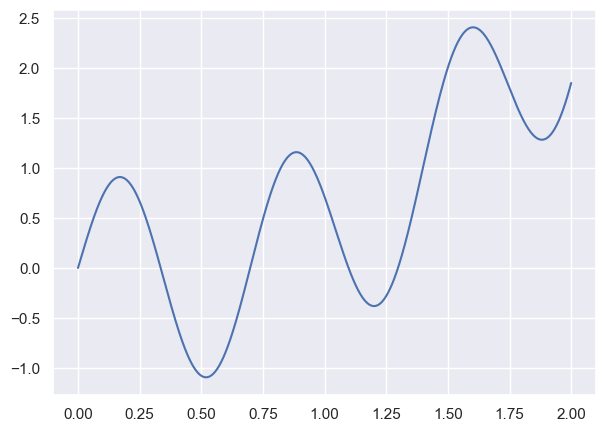

In [2]:
# set up true objective
def f1(x):
    return np.sin(9*x) + x**2 - 0.7*x
    #return np.sin(9*x) + x**2 -0.7*x -0.2* x**3
bounds = (0, 2)
x_star = np.linspace(*bounds, 10000)
f_star = f1(x_star)
true_max = np.max(f_star)
true_max_location = x_star[np.argmax(f_star)]

plt.figure(figsize=(7,5))
plt.plot(x_star, f_star)

In [3]:
# define kenel
dim = 1
kern_signal = C(1.0, (1e-3, 1e3)) * Matern(
            length_scale=np.ones(dim),
            length_scale_bounds=(1e-2, 1e2),
            nu=2.5,
        )
kern_noise = WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e1),
    )
kernel=kern_signal + kern_noise

# create starting data
std_noise = 0.3
np.random.seed(42)
n_init = 5
#x_init = np.random.uniform(low=bounds[0], high=bounds[1], size=n_init)
#x_init = np.linspace(bounds[0], bounds[1],n_init)
x_init = np.linspace(bounds[0], 1.25, 5)
print(x_init)
y_init = f1(x_init) + np.random.normal(0, std_noise, size=n_init)

# optimizer parameter -linear increase g
n_iter = 30
g_max = 3
acq_samples = 10
optimizer = bo.BayesianOptimizer(
    func = f1,
    kernel = kernel,
    bounds = np.array(bounds).reshape(dim, 2),
    g= np.linspace(0, g_max, n_iter),
    alpha = np.ones(n_iter),
    x_init = x_init.reshape(-1,dim),
    y_init = y_init.reshape(-1,1),
    xi = 0,
    n_iter= n_iter,
    acq_samples=acq_samples, # num starting points to optimize acquization
    random_state=42,

)

# run optimization
opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, visualize=False, verbose= False)
print(opt_result)
linear_g_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
g_result = {"linear_increase":linear_g_result}

[0.     0.3125 0.625  0.9375 1.25  ]


  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:33<00:00,  1.10s/it]

{'best_iteration_observed': 25, 'best_observed': 2.87790918074835, 'best_observed_x': array([1.61033168]), 'best_iteration_regret': 29, 'inst_regrets': array([1.34864386e+00, 1.44254993e+00, 2.94750962e+00, 1.36654173e+00,
       1.40895834e+00, 1.25116570e+00, 1.25328470e+00, 1.24928789e+00,
       1.27183309e+00, 1.25700598e+00, 1.29328378e+00, 5.56816695e-01,
       5.56816695e-01, 1.11865736e+00, 5.56816695e-01, 5.56816695e-01,
       5.56816695e-01, 5.56816695e-01, 5.56816695e-01, 4.24629188e-02,
       3.85877384e-01, 3.71341102e-01, 4.76920743e-01, 1.70272572e-01,
       7.77104185e-02, 2.53172260e-03, 1.50426205e+00, 3.89274712e-03,
       1.58113133e-02, 2.04145041e-03])}


In [4]:
# linear decrease g
optimizer = bo.BayesianOptimizer(
    func = f1,
    kernel = kernel,
    bounds = np.array(bounds).reshape(dim, 2),
    g= np.linspace(g_max, 0, n_iter),
    alpha = np.ones(n_iter),
    x_init = x_init.reshape(-1,dim),
    y_init = y_init.reshape(-1,1),
    xi = 0,
    n_iter= n_iter,
    acq_samples=acq_samples, # num starting points to optimize acquization
    random_state=42,

)

# run optimization
opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, visualize=False, verbose= False)
print(opt_result)
linear_g_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
g_result["linear_decay"] = linear_g_result

  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:23<00:00,  1.28it/s]

{'best_iteration_observed': 21, 'best_observed': 3.0196540393485605, 'best_observed_x': array([1.60536017]), 'best_iteration_regret': 20, 'inst_regrets': array([1.34864385e+00, 1.47280171e+00, 2.94775274e+00, 1.26165855e+00,
       1.97382090e+00, 5.56816695e-01, 5.56816695e-01, 9.92882831e-01,
       5.56816695e-01, 9.82936364e-01, 4.03744043e-01, 1.12265127e+00,
       3.48987882e-02, 1.50239179e+00, 2.36934094e-01, 4.29782790e-04,
       1.26903781e-05, 1.35168206e-03, 9.40352875e-04, 2.04888199e-03,
       3.06609258e-06, 3.95085453e-04, 1.06892225e-03, 8.04410672e-04,
       5.11859807e-04, 3.10467871e-04, 1.66433486e+00, 4.41074690e-04,
       4.84118765e-04, 3.07477962e-04])}


  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  8.06it/s]


{'best_iteration_observed': 21, 'best_observed': 2.463232429567395, 'best_observed_x': array([2.]), 'best_iteration_regret': 14, 'inst_regrets': array([1.34864386, 1.41661185, 2.94745353, 1.36781384, 1.36787082,
       1.37000986, 1.3701241 , 1.37035431, 1.37081102, 1.36985097,
       1.36981726, 1.3689599 , 1.36890725, 1.36812757, 0.5568167 ,
       0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 1.41056649, 0.5568167 , 0.5568167 , 0.5568167 ])}


  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
 17%|█▋        | 5/30 [00:10<00:53,  2.13s/it]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:47<00:00,  1.60s/it]


{'best_iteration_observed': 21, 'best_observed': 2.463232429567395, 'best_observed_x': array([2.]), 'best_iteration_regret': 14, 'inst_regrets': array([1.34864385, 2.39299819, 2.58790401, 1.34937197, 1.29561455,
       1.52490229, 1.50005768, 1.48904873, 1.57830141, 1.42716203,
       1.4447935 , 1.92319792, 1.3358702 , 1.28885138, 0.5568167 ,
       0.5568167 , 0.84205936, 1.08250463, 0.61688062, 0.5568167 ,
       0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ])}


  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  7.92it/s]


...

{'best_iteration_observed': 21, 'best_observed': 2.992643476451524, 'best_observed_x': array([1.57548525]), 'best_iteration_regret': 14, 'inst_regrets': array([1.34864385e+00, 1.37768339e+00, 2.94775274e+00, 1.64759677e+00,
       1.25797741e+00, 1.49711467e+00, 1.56139306e+00, 1.58219970e+00,
       1.29379316e+00, 7.27648832e-01, 1.01175541e+00, 5.56816695e-01,
       5.56816695e-01, 5.56816695e-01, 5.43770045e-05, 2.11986231e-01,
       5.19080680e-02, 4.86488150e-02, 4.19019779e-02, 3.66474962e-02,
       2.11056409e-01, 2.74056484e-02, 5.43667591e-02, 2.77009422e-02,
       2.03119592e-02, 1.61249394e-02, 2.17805783e+00, 2.99580469e-02,
       3.32969453e-02, 1.88049688e-02])}


  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:18<00:00,  1.64it/s]


{'best_iteration_observed': 21, 'best_observed': 3.0185661317012693, 'best_observed_x': array([1.60840035]), 'best_iteration_regret': 16, 'inst_regrets': array([1.34864387e+00, 1.41321030e+00, 2.94766318e+00, 1.25411986e+00,
       1.90316124e+00, 5.56816695e-01, 7.26476567e-01, 1.05697955e+00,
       5.56816695e-01, 8.46651907e-01, 2.92223294e-01, 1.01742218e+00,
       7.03791059e-02, 1.50268480e+00, 4.13742724e-01, 9.86783326e-05,
       1.15522466e-07, 7.22034417e-04, 9.23830569e-04, 1.32213890e-03,
       1.12256026e+00, 1.48299310e-03, 4.89988401e-03, 4.42499769e-03,
       1.71694381e-03, 1.99003539e-04, 1.66433486e+00, 2.89191984e-05,
       3.85608914e-05, 3.00585415e-04])}


  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  7.87it/s]


{'best_iteration_observed': 21, 'best_observed': 3.0123985040466037, 'best_observed_x': array([1.58799774]), 'best_iteration_regret': 28, 'inst_regrets': array([1.34864385e+00, 1.37767928e+00, 2.94775274e+00, 1.71750599e+00,
       1.28134966e+00, 1.49707324e+00, 1.58345820e+00, 1.61095222e+00,
       9.53460104e-01, 1.10220990e+00, 7.74087565e-01, 2.36552095e-03,
       1.75362058e-01, 2.51478029e+00, 7.96932393e-03, 9.27247683e-02,
       6.24650225e-01, 1.89129969e-01, 1.10867235e+00, 9.32422684e-02,
       5.56816695e-01, 7.65062076e-03, 2.18454286e-03, 1.83014197e-03,
       7.09674878e-03, 1.18355687e-02, 1.66433486e+00, 2.83775615e-03,
       9.54018864e-04, 1.28008262e-02])}


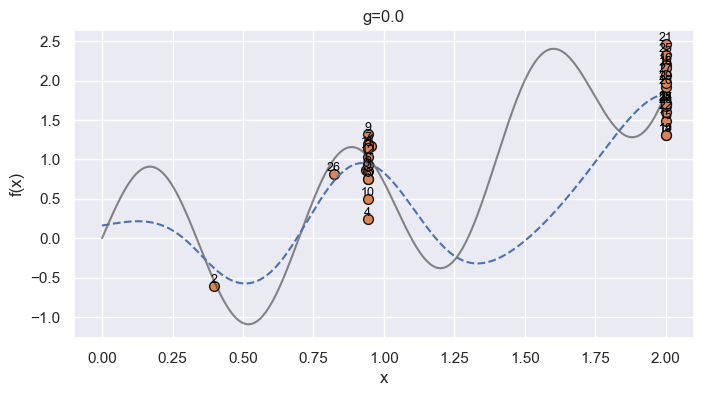

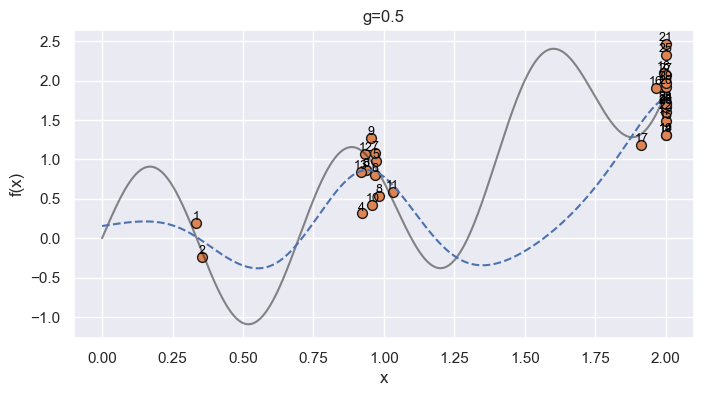

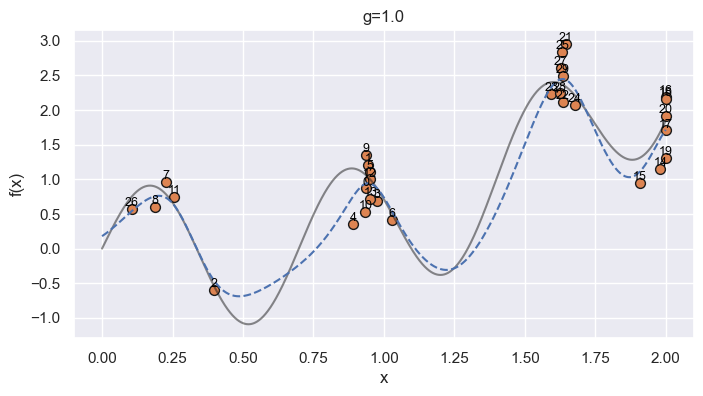

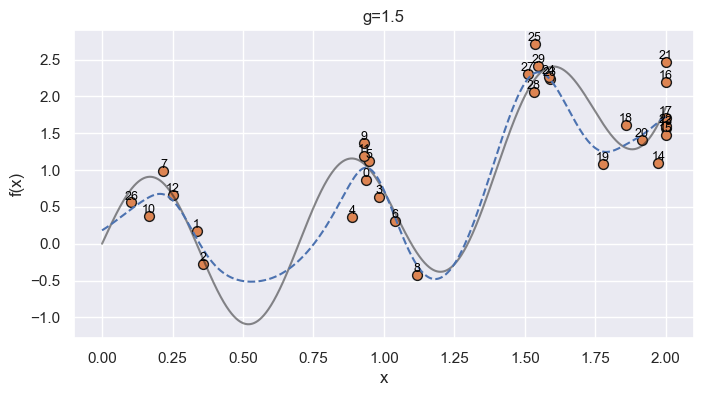

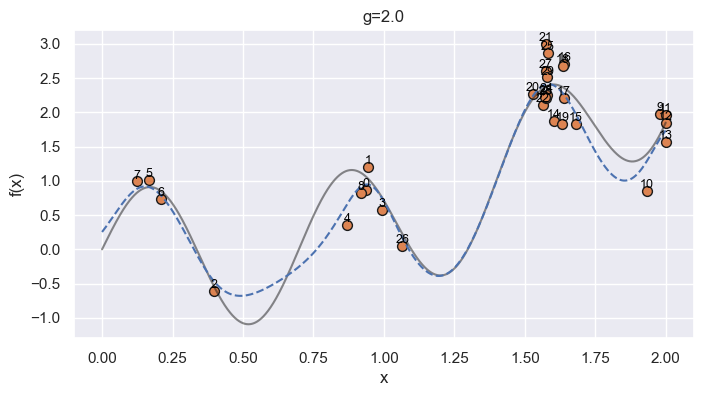

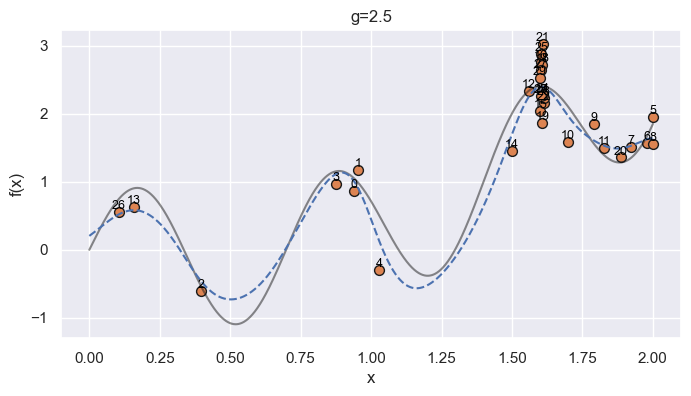

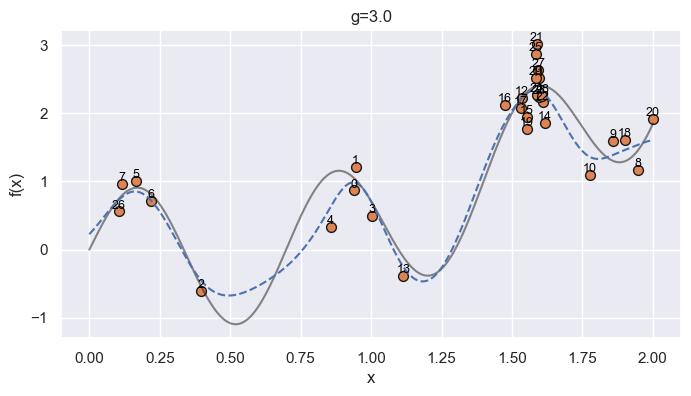

In [5]:
 #RUN FOR ALL gs
all_gs = np.arange(0, 3.5, 0.5)
for g in all_gs:
    optimizer = bo.BayesianOptimizer(
        func = f1,
        kernel = kernel,
        bounds = np.array(bounds).reshape(dim, 2),
        g= np.ones(n_iter)*g,
        alpha = np.ones(n_iter),
        x_init = x_init.reshape(-1,dim),
        y_init = y_init.reshape(-1,1),
        xi = 0,
        n_iter= n_iter,
        acq_samples=acq_samples, # num starting points to optimize acquization
        random_state=42
    )
    opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, verbose= False)
    print(opt_result)
    temp_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
    g_result[g] = temp_result
    # visualize
    plt.figure(figsize=(8,4))
    plt.plot(x_star, f_star, 'k-', label='true f(x)', alpha=0.5)
    data_x, data_y = optimizer.X[n_init:], optimizer.Y[n_init:]
    plt.scatter(data_x, data_y, c='C1', s=50, edgecolor='k')
    for i,(x,y) in enumerate(zip(data_x,data_y)):
        plt.text(x, y, str(i), color='black',
                fontsize=9, ha='center', va='bottom')
    plt.xlabel('x'); plt.ylabel('f(x)')
    plt.title(f"g={g}")
    mu, std = optimizer.predict_tempered(x_star.reshape(-1, 1),1)
    plt.plot(x_star, mu, 'b--', label='GP mean')
    # ±1σ band

In [6]:
cols = ['cumulative_regrets', 'best_iteration_observed', 'best_observed', 'best_observed_x', 'best_iteration_regret']
g_result_df = pd.DataFrame({
    key: {c: sub.get(c, None) for c in cols}
    for key, sub in g_result.items()
}).T

In [7]:
g_result_df

,cumulative_regrets,best_iteration_observed,best_observed,best_observed_x,best_iteration_regret
linear_increase,24.159563,25,2.877909,[1.6103316827362046],29
linear_decay,17.625012,21,3.019654,[1.6053601737059844],20
0.0,30.538173,21,2.463232,[2.0],14
0.5,32.266779,21,2.463232,[2.0],14
1.0,28.818118,21,2.950767,[1.6460424159207951],23
1.5,32.158028,25,2.708176,[1.5356327664361007],23
2.0,20.93224,21,2.992643,[1.5754852514681335],14
2.5,18.710046,21,3.018566,[1.6084003548213321],16
3.0,23.271411,21,3.012399,[1.5879977377321783],28
